# Assignment 3.4: Mini NeRF Rendering

In this notebook you will implement the **rendering** part of NeRF. We provide an analytic radiance field instead of asking you to train an MLP, so this problem stays lightweight and focuses on the core equations.

Implementation conventions:
- Use pixel centers when generating camera rays.
- Normalize camera-space ray directions before rotating them with `c2w[:3, :3]`.
- Sample `num_samples` points uniformly in depth between `near` and `far`.
- Compute depth as the weighted sum of sampled `t_vals` without extra normalization.

Useful formulas:
- `alpha_i = 1 - exp(-sigma_i * delta_i)`
- `T_i = prod_{j < i} (1 - alpha_j)`
- `weight_i = T_i * alpha_i`
- `C(r) = sum_i weight_i * c_i`

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scene import get_camera_config, query_radiance_field

In [2]:
cfg = get_camera_config()
print(cfg)

{'H': 64, 'W': 64, 'focal': 70.0, 'near': 1.5, 'far': 5.0, 'num_samples': 64, 'c2w': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]], dtype=float32)}


In [3]:
def generate_rays(H, W, focal, c2w):
    # 1) generate per-pixel camera-space directions
    i, j = np.meshgrid(
        np.arange(W, dtype=np.float32),
        np.arange(H, dtype=np.float32),
        indexing='xy',
    )
    dirs_cam = np.stack(
        [
            (i - W * 0.5) / focal,
            -(j - H * 0.5) / focal,
            np.ones_like(i),
        ],
        axis=-1,
    )

    # 2) normalize them
    dirs_cam = dirs_cam / (np.linalg.norm(dirs_cam, axis=-1, keepdims=True) + 1e-8)

    # 3) rotate into world frame
    R = c2w[:3, :3]
    rays_d = dirs_cam @ R.T

    # 4) broadcast camera center as ray origins
    rays_o = np.broadcast_to(c2w[:3, 3], rays_d.shape)

    return rays_o.astype(np.float32), rays_d.astype(np.float32)


In [4]:
def sample_points(rays_o, rays_d, near, far, num_samples):
    # uniformly sample num_samples depth values between near and far
    # and return sampled 3D points with shape [H, W, num_samples, 3].
    t_vals = np.linspace(near, far, num_samples, dtype=np.float32)

    points = rays_o[..., None, :] + rays_d[..., None, :] * t_vals[None, None, :, None]

    deltas = np.empty_like(t_vals)
    if num_samples > 1:
        deltas[:-1] = t_vals[1:] - t_vals[:-1]
        deltas[-1] = deltas[-2]
    else:
        deltas[0] = far - near

    return points.astype(np.float32), t_vals, deltas


In [5]:
def volume_render(sigmas, rgbs, deltas, t_vals):
    # alpha_i = 1 - exp(-sigma_i * delta_i)
    if np.ndim(deltas) == 1:
        deltas_ = deltas[None, None, :]
    else:
        deltas_ = deltas

    alphas = 1.0 - np.exp(-sigmas * deltas_) # shape: [H, W, num_samples]

    # T_i = product_{j < i} (1 - alpha_j)
    trans = np.cumprod(1.0 - alphas + 1e-10, axis=-1)
    # [(1-alpha_0), (1-alpha_0)*(1-alpha_1), (1-alpha_0)*(1-alpha_1)*(1-alpha_2), ...]
    # shift right and set first element to 1
    T = np.concatenate([np.ones_like(trans[..., :1]), trans[..., :-1]], axis=-1)
    # [1, (1-alpha_0), (1-alpha_0)*(1-alpha_1), ...]
    # weight_i = T_i * alpha_i
    weights = T * alphas

    # weighted color and depth
    pred_rgb = np.sum(weights[..., None] * rgbs, axis=-2)

    if np.ndim(t_vals) == 1:
        t_ = t_vals[None, None, :]
    else:
        t_ = t_vals
    pred_depth = np.sum(weights * t_, axis=-1)

    return pred_rgb.astype(np.float32), pred_depth.astype(np.float32), weights.astype(np.float32)


In [6]:
H, W = cfg['H'], cfg['W']
focal = cfg['focal']
near = cfg['near']
far = cfg['far']
num_samples = cfg['num_samples']
c2w = cfg['c2w']

rays_o, rays_d = generate_rays(H, W, focal, c2w)
points, t_vals, deltas = sample_points(rays_o, rays_d, near, far, num_samples)
sigmas, rgbs = query_radiance_field(points)
pred_rgb, pred_depth, weights = volume_render(sigmas, rgbs, deltas, t_vals)

print('pred_rgb shape:', pred_rgb.shape)
print('pred_depth shape:', pred_depth.shape)

pred_rgb shape: (64, 64, 3)
pred_depth shape: (64, 64)


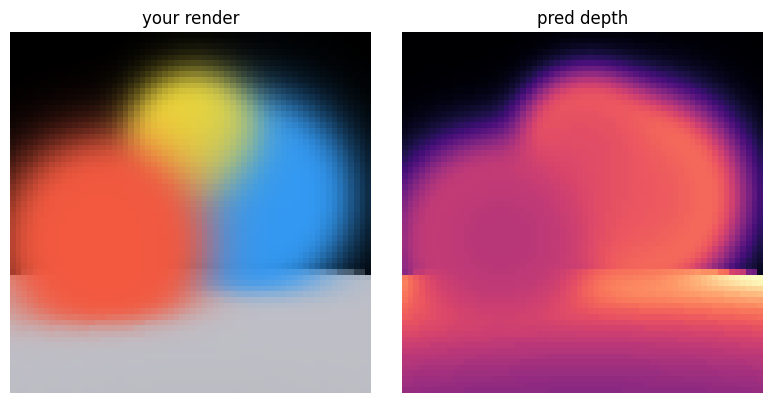

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.clip(pred_rgb, 0.0, 1.0))
axes[0].set_title('your render')
axes[1].imshow(pred_depth, cmap='magma')
axes[1].set_title('pred depth')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

In [8]:
opacity = np.sum(weights, axis=-1)
metrics = {
    'rgb_min': float(pred_rgb.min()),
    'rgb_max': float(pred_rgb.max()),
    'depth_min': float(pred_depth.min()),
    'depth_max': float(pred_depth.max()),
    'mean_opacity': float(opacity.mean()),
}
print(metrics)

os.makedirs('../results', exist_ok=True)
np.save('../results/mini_nerf_rgb.npy', pred_rgb)
np.save('../results/mini_nerf_depth.npy', pred_depth)
np.save('../results/mini_nerf_metrics.npy', metrics)

{'rgb_min': 0.00010084416135214269, 'rgb_max': 0.9499354362487793, 'depth_min': 0.0009414689266122878, 'depth_max': 4.366939067840576, 'mean_opacity': 0.757992148399353}


Expected deliverables: save `mini_nerf_rgb.npy`, `mini_nerf_depth.npy`, and `mini_nerf_metrics.npy` to `results/`. The metrics file should contain your self-check statistics, while grading should compare your outputs against a hidden reference. No training is required for this problem.